# Active reset (ConditionalReset) verification

In [5]:
from pathlib import Path

from qblox_lab.config.hardware import create_hardware_agent
from qblox_lab.config.sessions import CONFIG_DIR, SESSIONS
from qblox_lab.experiments.dev_active_reset import ActiveReset

## Run parameters

In [6]:
SESSION = SESSIONS["AS_QRC"]
HARDWARE_CONFIG = SESSION.hardware_config
DEVICE_CONFIG = SESSION.device_config
FLUX_CONFIG = SESSION.flux_config  # If None, leave the existing hardware flux unchanged
OUTPUT_DIR = Path("data")

QUBITS = ["q1"]
REPETITIONS = 500

TIMEOUT = 300
CREATE_DUMMY_CONNECTIONS = False

PLOT_RESULTS = True

## Hardware and experiment

In [7]:
hardware_agent = create_hardware_agent(
    hardware_configuration=HARDWARE_CONFIG,
    device_configuration=DEVICE_CONFIG,
    output_dir=OUTPUT_DIR,
    create_dummy_connections=CREATE_DUMMY_CONNECTIONS,
)

experiment = ActiveReset(
    hardware_agent=hardware_agent,
    qubits=QUBITS,
    flux_config=FLUX_CONFIG,
)

## Measurement

In [8]:
dataset = experiment.run_measurement(
    repetitions=REPETITIONS,
    timeout=TIMEOUT,
)
dataset

/home/reny871224/micromamba/envs/qblox-training/lib/python3.10/site-packages/qblox_scheduler/backends/qblox/compiler_abc.py:285: UserWarning: Exact capabilities for ISA version 2.1 not found, using capabilities for version 2.2.
  warnings.warn(


<xarray.Dataset> Size: 40kB
Dimensions:            (acq_index_cond_q1: 2, acq_index_S21_q1: 1000)
Coordinates:
    state_q1           (acq_index_S21_q1) int64 8kB 0 1 0 1 0 1 ... 0 1 0 1 0 1
    rep_q1             (acq_index_S21_q1) float64 8kB 0.0 0.0 ... 499.0 499.0
  * acq_index_S21_q1   (acq_index_S21_q1) int64 8kB 0 1 2 3 ... 996 997 998 999
  * acq_index_cond_q1  (acq_index_cond_q1) int64 16B 0 1
Data variables:
    cond_q1            (acq_index_cond_q1) float64 16B 0.324 0.44
    S21_q1             (acq_index_S21_q1) complex128 16kB (0.0010949240922927...
Attributes:
    tuid:     20260820-083349-084-8c26ab

## Optional: Simulated data

In [ ]:
# dataset = experiment.simulated_data(
#     repetitions=REPETITIONS,
#     reset_fidelity=0.95,
#     noise=0.01,
#     seed=42,
# )

## Analysis

In [9]:
results = experiment.analysis()
for qubit, result in results.items():
    print(f"{qubit}: success={result.success}")
    print(f"  prepared |0> mean IQ: {result.prep_0.mean():.4g}")
    print(f"  prepared |1> mean IQ: {result.prep_1.mean():.4g}")

q1: success=True
  prepared |0> mean IQ: 0.0002958-0.0004707j
  prepared |1> mean IQ: 0.0003379-0.0004188j


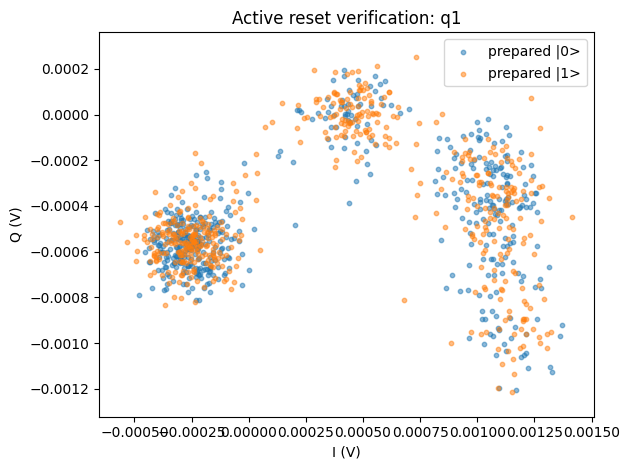

In [10]:
if PLOT_RESULTS:
    experiment.plot()